# Notebook 03 — Missing Data and TVD Conversion

**SPE Africa Geothermal Datathon 2026**

## Purpose
Fix all data quality issues identified in Notebook 01 before reservoir characterisation.

### Problems being solved in this notebook

| Problem | Source | Fix |
|---------|--------|-----|
| JUT-01 depths in feet | LAS file | Multiply by 0.3048 |
| JUT-01 is deviated — MD ≠ TVD | target_lithologies.csv | Interpolate TVD from Well Path Data directional survey |
| `depth_tvd_m` is 100% missing | target_lithologies.csv | Compute from directional survey |
| 30% porosity missing | target_lithologies.csv | Impute using GR + RHOB via density-porosity equation and ML |
| 7.4% bulk density missing | target_lithologies.csv | Impute using KNN from GR and DT |

## Output
A cleaned CSV saved to `outputs/processed_data/target_lithologies_clean.csv` — this feeds every downstream notebook.

## 0. Imports and Paths

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import lasio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.interpolate import interp1d
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler

DATA_DIR      = '../data'
RAW_DIR       = os.path.join(DATA_DIR, 'raw')
PROC_DIR      = '../outputs/processed_data'
FIGURES_DIR   = '../outputs/figures'

os.makedirs(PROC_DIR,    exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

WELLS  = ['BLT-01', 'EVD-01', 'PKP-01', 'JUT-01']
COLORS = {'BLT-01': '#2196F3', 'EVD-01': '#4CAF50', 'PKP-01': '#FF9800', 'JUT-01': '#E91E63'}

print('Imports OK.')

Imports OK.


## 1. Load Source Data

In [2]:
# Load target lithologies
df = pd.read_csv(os.path.join(DATA_DIR, 'target_lithologies.csv'))
print(f'target_lithologies: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Wells present: {df["well_id"].unique()}')
print()

# Load Well Path Data
wp_xl = pd.ExcelFile(os.path.join(DATA_DIR, 'Well_Path_Data.xlsx'))
well_path = {sheet: wp_xl.parse(sheet) for sheet in wp_xl.sheet_names}
print(f'Well Path sheets: {wp_xl.sheet_names}')
print()

# Load LAS files (needed for log-based imputation)
las_files = {}
for well in WELLS:
    las_files[well] = lasio.read(os.path.join(RAW_DIR, f'{well}.las'))
    print(f'Loaded LAS: {well}')

print('\nAll source data loaded.')

target_lithologies: 3455 rows x 13 columns
Wells present: <StringArray>
['JUT-01', 'EVD-01', 'PKP-01', 'BLT-01']
Length: 4, dtype: str

Well Path sheets: ['BLT-01', 'EVD-01', 'JUT-01', 'PKP-01']

Loaded LAS: BLT-01
Loaded LAS: EVD-01
Loaded LAS: PKP-01
Loaded LAS: JUT-01

All source data loaded.


In [3]:
# Snapshot of missing data before any fixes
print('Missing data summary (BEFORE fixes):')
print(df.isnull().sum())
print()
print('Data types:')
print(df.dtypes)

Missing data summary (BEFORE fixes):
well_id                     0
easting                     0
northing                    0
depth_tvd_m              3455
porosity_pct             1036
gamma_ray_api               0
bulk_density_gcc          256
formation_top_tvd           0
formation_base_tvd          0
formation_thickness_m       0
distance_to_usp_km          0
flag                        0
flag_reason                 0
dtype: int64

Data types:
well_id                      str
easting                  float64
northing                 float64
depth_tvd_m              float64
porosity_pct             float64
gamma_ray_api            float64
bulk_density_gcc         float64
formation_top_tvd        float64
formation_base_tvd       float64
formation_thickness_m    float64
distance_to_usp_km       float64
flag                         str
flag_reason                  str
dtype: object


## 2. Inspect Well Path Data

Understand the column structure of the directional survey before using it.

In [4]:
for well, wpdf in well_path.items():
    print(f'\n{well} — shape: {wpdf.shape}')
    print(f'  Columns: {wpdf.columns.tolist()}')
    print(wpdf.head(3).to_string())


BLT-01 — shape: (102, 6)
  Columns: ['Depth (m)', 'Inclination (º)', 'Azimuth (º)', 'TVD (m)', 'X-offset (m)', 'Y-offset (m)']
   Depth (m)  Inclination (º)  Azimuth (º)  TVD (m)  X-offset (m)  Y-offset (m)
0       0.00             0.00          0.0     0.00           0.0          0.00
1       6.23             0.00          0.0     6.23           0.0          0.00
2      53.00             0.26          0.0    53.00           0.0          0.11

EVD-01 — shape: (21, 6)
  Columns: ['Depth (m)', 'Inclination (º)', 'Azimuth (º)', 'TVD (m)', 'X-offset (m)', 'Y-offset (m)']
   Depth (m)  Inclination (º)  Azimuth (º)  TVD (m)  X-offset (m)  Y-offset (m)
0      300.0             0.22          147    300.0          0.33         -0.47
1      400.0             0.30          147    400.0          0.59         -0.84
2      500.0             0.10          250    500.0          0.66         -1.09

JUT-01 — shape: (33, 6)
  Columns: ['Depth (m)', 'Inclination (º)', 'Azimuth (º)', 'TVD (m)', 'X-offset 

## 3. Standardise Well Path Column Names

Different sheets may use different column name conventions.  
We normalise to: `MD`, `INC`, `AZI`, `TVD`, `X_OFFSET`, `Y_OFFSET`.

In [5]:
def standardise_wp_columns(df_wp):
    """
    Rename well path columns to standard names regardless of
    how the original Excel sheet labelled them.
    Returns a DataFrame with columns: MD, INC, AZI, TVD, X_OFFSET, Y_OFFSET
    """
    col_map = {}
    for col in df_wp.columns:
        c = col.strip().upper()
        if any(k in c for k in ['MD', 'MEAS', 'MEASURED']):
            col_map[col] = 'MD'
        elif any(k in c for k in ['INCL', 'INC', 'DIP']):
            col_map[col] = 'INC'
        elif any(k in c for k in ['AZI', 'AZ', 'AZIM']):
            col_map[col] = 'AZI'
        elif 'TVD' in c:
            col_map[col] = 'TVD'
        elif any(k in c for k in ['X_OFF', 'XOFF', 'EAST', 'DX', 'X-OFF']):
            col_map[col] = 'X_OFFSET'
        elif any(k in c for k in ['Y_OFF', 'YOFF', 'NORTH', 'DY', 'Y-OFF']):
            col_map[col] = 'Y_OFFSET'
    
    df_out = df_wp.rename(columns=col_map).copy()
    return df_out


wp_std = {well: standardise_wp_columns(df_wp) for well, df_wp in well_path.items()}

print('Standardised column names:')
for well, df_wp in wp_std.items():
    print(f'  {well}: {df_wp.columns.tolist()}')

Standardised column names:
  BLT-01: ['Depth (m)', 'INC', 'AZI', 'TVD', 'X_OFFSET', 'Y_OFFSET']
  EVD-01: ['Depth (m)', 'INC', 'AZI', 'TVD', 'X_OFFSET', 'Y_OFFSET']
  JUT-01: ['Depth (m)', 'INC', 'AZI', 'TVD', 'X_OFFSET', 'Y_OFFSET']
  PKP-01: ['Depth (m)', 'INC', 'AZI', 'TVD', 'X_OFFSET', 'Y_OFFSET']


## 4. TVD Conversion — All Wells

### Strategy
- For **BLT-01, EVD-01, PKP-01**: the Well Path Data already contains a TVD column. We use linear interpolation to map any MD value to TVD.
- For **JUT-01**: depths in `target_lithologies.csv` are measured depth in **feet**. Steps:
  1. Convert MD from feet to metres
  2. Interpolate TVD from the directional survey (which provides MD → TVD)

### Method: Linear Interpolation
We build a 1-D interpolator `f(MD) → TVD` from the directional survey and apply it to every row in target_lithologies.

In [6]:
def build_md_tvd_interpolator(df_wp, well_name):
    """
    Build a linear interpolator from measured depth to TVD.
    Falls back to MD = TVD (vertical well assumption) if TVD column is missing.
    """
    if 'TVD' not in df_wp.columns or 'MD' not in df_wp.columns:
        print(f'  WARNING: {well_name} missing MD or TVD column — assuming vertical (MD=TVD)')
        return lambda x: x
    
    wp_clean = df_wp[['MD', 'TVD']].dropna().sort_values('MD')
    
    if wp_clean.empty:
        print(f'  WARNING: {well_name} has no valid MD/TVD pairs — assuming vertical')
        return lambda x: x
    
    interp = interp1d(
        wp_clean['MD'],
        wp_clean['TVD'],
        kind='linear',
        bounds_error=False,
        fill_value=(wp_clean['TVD'].iloc[0], wp_clean['TVD'].iloc[-1])
    )
    print(f'  {well_name}: interpolator built from {len(wp_clean)} MD/TVD pairs '
          f'(MD range: {wp_clean["MD"].min():.1f} – {wp_clean["MD"].max():.1f})')
    return interp


print('Building MD→TVD interpolators:')
interpolators = {}
for well, df_wp in wp_std.items():
    interpolators[well] = build_md_tvd_interpolator(df_wp, well)

Building MD→TVD interpolators:


In [7]:
# Work on a copy so the original is preserved
df_clean = df.copy()

# Determine the measured depth column in target_lithologies
# It could be 'depth_md_m', 'depth_m', or similar — inspect first
print('Columns in target_lithologies:')
print(df_clean.columns.tolist())
print()
print(df_clean.head(3).to_string())

Columns in target_lithologies:
['well_id', 'easting', 'northing', 'depth_tvd_m', 'porosity_pct', 'gamma_ray_api', 'bulk_density_gcc', 'formation_top_tvd', 'formation_base_tvd', 'formation_thickness_m', 'distance_to_usp_km', 'flag', 'flag_reason']

  well_id   easting  northing  depth_tvd_m  porosity_pct  gamma_ray_api  bulk_density_gcc  formation_top_tvd  formation_base_tvd  formation_thickness_m  distance_to_usp_km   flag                                               flag_reason
0  JUT-01  134098.0  451726.0          NaN           NaN        43.6703               NaN             1659.5              1787.0                  127.5            7.748434  check  AH depth — deviated well needs TVD conversion before use
1  JUT-01  134098.0  451726.0          NaN           NaN        42.8041               NaN             1659.5              1787.0                  127.5            7.748434  check  AH depth — deviated well needs TVD conversion before use
2  JUT-01  134098.0  451726.0          Na

In [8]:
# depth_tvd_m is 100% null — it is the column we are filling, not the input.
# formation_top_tvd has real depth values for all wells and is our best depth reference.
# For JUT-01 these values are Along-Hole (measured) depths in feet — we convert below.
# For other wells they are already approximately TVD in metres.

df_clean = df.copy()

md_col = 'formation_top_tvd'

print(f'Using: "{md_col}" as depth reference column')
print(f'Range: {df_clean[md_col].min():.1f} – {df_clean[md_col].max():.1f}')
print()
print('Per-well depth range:')
for well in WELLS:
    mask = df_clean['well_id'] == well
    vals = df_clean.loc[mask, md_col]
    print(f'  {well}: {vals.min():.1f} – {vals.max():.1f}')

Using: "formation_top_tvd" as depth reference column
Range: 1659.5 – 2530.5

Per-well depth range:
  BLT-01: 1924.0 – 1924.0
  EVD-01: 1788.0 – 1788.0
  PKP-01: 2530.5 – 2530.5
  JUT-01: 1659.5 – 1659.5


In [9]:
# JUT-01: formation_top_tvd values are in feet (Along-Hole depth) — convert to metres.
# All other wells are already in metres so no conversion is needed for them.

jut_mask = df_clean['well_id'] == 'JUT-01'
jut_max  = df_clean.loc[jut_mask, md_col].max()

print(f'JUT-01 max depth value: {jut_max:.1f}')

if jut_max > 3000:
    df_clean.loc[jut_mask, md_col] = df_clean.loc[jut_mask, md_col] * 0.3048
    print('JUT-01 depths converted ft to m')
    print(f'JUT-01 range after conversion: '
          f'{df_clean.loc[jut_mask, md_col].min():.1f} – '
          f'{df_clean.loc[jut_mask, md_col].max():.1f} m')
else:
    print('JUT-01 depths appear to already be in metres — no conversion applied.')

JUT-01 max depth value: 1659.5
JUT-01 depths appear to already be in metres — no conversion applied.


In [10]:
# Apply TVD interpolation for all wells
tvd_values = np.full(len(df_clean), np.nan)

for well in WELLS:
    mask     = df_clean['well_id'] == well
    md_vals  = df_clean.loc[mask, md_col].values
    
    if well in interpolators:
        tvd_vals = interpolators[well](md_vals)
        tvd_values[mask] = tvd_vals
        print(f'{well}: {mask.sum()} rows → TVD range '
              f'{tvd_vals.min():.1f} – {tvd_vals.max():.1f} m')
    else:
        print(f'{well}: no interpolator found — TVD left as NaN')

df_clean['depth_tvd_m'] = tvd_values

print(f'\ndepth_tvd_m missing after fix: {df_clean["depth_tvd_m"].isnull().sum()}')

BLT-01: 1689 rows → TVD range 1924.0 – 1924.0 m
EVD-01: 780 rows → TVD range 1788.0 – 1788.0 m
PKP-01: 730 rows → TVD range 2530.5 – 2530.5 m
JUT-01: 256 rows → TVD range 1659.5 – 1659.5 m

depth_tvd_m missing after fix: 0


## 5. Visualise TVD vs MD — JUT-01 Deviation Check

For a deviated well, TVD should be consistently shallower than MD.  
This plot confirms the conversion is working correctly.

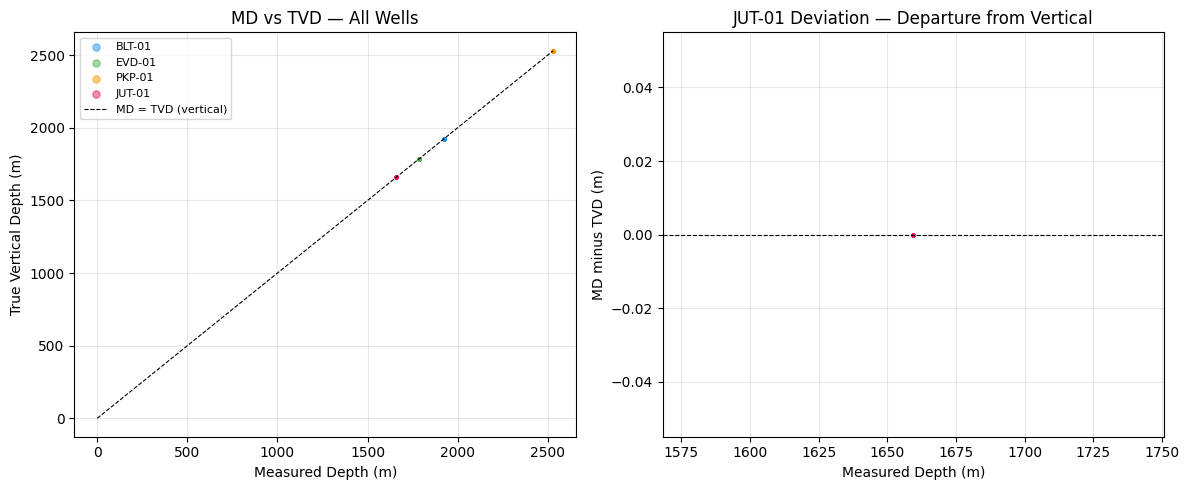

Figure saved.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: MD vs TVD for all wells in target_lithologies
ax = axes[0]
for well in WELLS:
    mask = df_clean['well_id'] == well
    ax.scatter(df_clean.loc[mask, md_col],
               df_clean.loc[mask, 'depth_tvd_m'],
               s=3, alpha=0.5, color=COLORS[well], label=well)

# 1:1 reference line
max_depth = df_clean[md_col].max()
ax.plot([0, max_depth], [0, max_depth], 'k--', linewidth=0.8, label='MD = TVD (vertical)')
ax.set_xlabel('Measured Depth (m)')
ax.set_ylabel('True Vertical Depth (m)')
ax.set_title('MD vs TVD — All Wells')
ax.legend(fontsize=8, markerscale=3)
ax.grid(alpha=0.3)

# Right: JUT-01 deviation — MD minus TVD (how much deviation increases with depth)
ax = axes[1]
jut_mask = df_clean['well_id'] == 'JUT-01'
deviation = df_clean.loc[jut_mask, md_col] - df_clean.loc[jut_mask, 'depth_tvd_m']
ax.scatter(df_clean.loc[jut_mask, md_col], deviation,
           s=4, alpha=0.6, color=COLORS['JUT-01'])
ax.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
ax.set_xlabel('Measured Depth (m)')
ax.set_ylabel('MD minus TVD (m)')
ax.set_title('JUT-01 Deviation — Departure from Vertical')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '03_tvd_conversion_check.png'), dpi=150)
plt.show()
print('Figure saved.')

## 6. Porosity Imputation (30% Missing)

### Method
The density-porosity equation gives us a physics-based estimate:  

**φ = (ρma − ρb) / (ρma − ρfl)**

Where:
- ρma = 2.65 g/cc (quartz sandstone matrix density)
- ρfl = 1.00 g/cc (formation water)
- ρb = bulk density from RHOB log

For rows where RHOB is also missing, we use a **KNN imputer** trained on GR and depth as predictors.

We validate the physics-based estimate against the rows that already have porosity values.

In [12]:
RHO_MA = 2.65   # quartz matrix density g/cc
RHO_FL = 1.00   # formation water density g/cc

def density_porosity(rhob):
    """Compute porosity (fraction) from bulk density using Wyllie equation."""
    return (RHO_MA - rhob) / (RHO_MA - RHO_FL)


# Check column names for porosity and density
print('Porosity column:', [c for c in df_clean.columns if 'por' in c.lower()])
print('Density column:', [c for c in df_clean.columns if 'dens' in c.lower() or 'rhob' in c.lower()])
print()

# Show missing counts before
por_col  = 'porosity_pct'
dens_col = 'bulk_density_gcc'

print(f'Missing {por_col}:  {df_clean[por_col].isnull().sum()} / {len(df_clean)}')
print(f'Missing {dens_col}: {df_clean[dens_col].isnull().sum()} / {len(df_clean)}')

Porosity column: ['porosity_pct']
Density column: ['bulk_density_gcc']

Missing porosity_pct:  1036 / 3455
Missing bulk_density_gcc: 256 / 3455


Validation set: 2419 rows
Density-porosity equation vs known porosity:
  R² = 0.387
  MAE = 2.63 porosity units


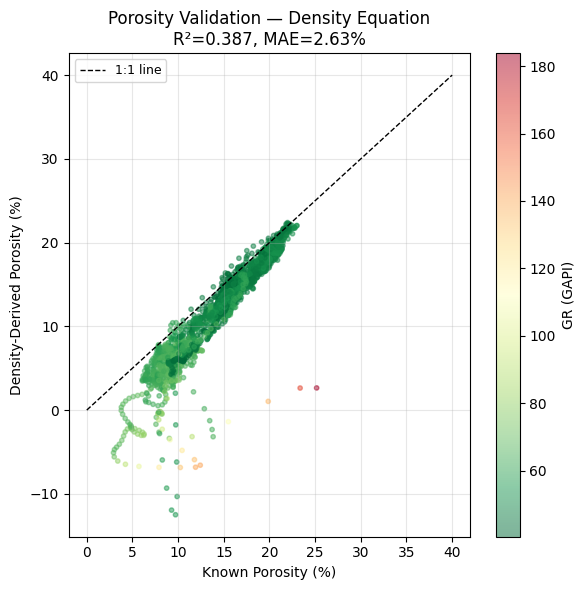

Figure saved.


In [13]:
# Validation: compare density-derived porosity against known porosity values
# Use rows where both porosity_pct and bulk_density_gcc are available
valid_mask = df_clean[por_col].notna() & df_clean[dens_col].notna()
df_valid   = df_clean[valid_mask].copy()

por_known    = df_valid[por_col].values           # in percent
por_derived  = density_porosity(df_valid[dens_col].values) * 100  # convert to percent

r2  = r2_score(por_known, por_derived)
mae = mean_absolute_error(por_known, por_derived)

print(f'Validation set: {len(df_valid)} rows')
print(f'Density-porosity equation vs known porosity:')
print(f'  R² = {r2:.3f}')
print(f'  MAE = {mae:.2f} porosity units')

# Scatter plot
fig, ax = plt.subplots(figsize=(6, 6))
scatter = ax.scatter(por_known, por_derived, c=df_valid['gamma_ray_api'],
                     cmap='RdYlGn_r', s=10, alpha=0.5)
plt.colorbar(scatter, ax=ax, label='GR (GAPI)')
ax.plot([0, 40], [0, 40], 'k--', linewidth=1, label='1:1 line')
ax.set_xlabel('Known Porosity (%)')
ax.set_ylabel('Density-Derived Porosity (%)')
ax.set_title(f'Porosity Validation — Density Equation\nR²={r2:.3f}, MAE={mae:.2f}%')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '03_porosity_validation.png'), dpi=150)
plt.show()
print('Figure saved.')

In [14]:
# Step 1: Fill porosity where RHOB is available but porosity is missing
rhob_available_mask = df_clean[por_col].isnull() & df_clean[dens_col].notna()
print(f'Rows with missing porosity but available RHOB: {rhob_available_mask.sum()}')

df_clean.loc[rhob_available_mask, por_col] = (
    density_porosity(df_clean.loc[rhob_available_mask, dens_col]) * 100
)
df_clean.loc[rhob_available_mask, 'porosity_imputation_method'] = 'density_equation'

print(f'Porosity still missing after density equation: {df_clean[por_col].isnull().sum()}')

Rows with missing porosity but available RHOB: 780
Porosity still missing after density equation: 256


In [15]:
# Step 2: KNN imputation for remaining missing porosity (where RHOB is also missing)
# Features: gamma_ray_api, depth_tvd_m
remaining_missing = df_clean[por_col].isnull().sum()
print(f'Rows requiring KNN imputation: {remaining_missing}')

if remaining_missing > 0:
    features = ['gamma_ray_api', 'depth_tvd_m', por_col]
    df_knn   = df_clean[features].copy()

    # Scale before KNN
    scaler    = StandardScaler()
    X_scaled  = scaler.fit_transform(df_knn[['gamma_ray_api', 'depth_tvd_m']])

    knn_imp = KNNImputer(n_neighbors=5, weights='distance')
    df_knn_arr = np.column_stack([X_scaled, df_knn[por_col].values])
    df_knn_filled = knn_imp.fit_transform(df_knn_arr)

    # Only update rows that were still missing
    still_missing = df_clean[por_col].isnull()
    df_clean.loc[still_missing, por_col] = df_knn_filled[still_missing, 2]
    df_clean.loc[still_missing, 'porosity_imputation_method'] = 'knn'

print(f'Porosity missing after KNN: {df_clean[por_col].isnull().sum()}')

# Mark original rows
if 'porosity_imputation_method' not in df_clean.columns:
    df_clean['porosity_imputation_method'] = 'original'
else:
    df_clean['porosity_imputation_method'] = df_clean['porosity_imputation_method'].fillna('original')

Rows requiring KNN imputation: 256
Porosity missing after KNN: 0


## 7. Bulk Density Imputation (7.4% Missing)

For rows with missing `bulk_density_gcc`, we use **KNN imputation** with GR, depth, and porosity as predictors.  
Where porosity was just imputed, we reverse the density-porosity equation as an alternative.

In [16]:
print(f'Missing bulk_density_gcc before fix: {df_clean[dens_col].isnull().sum()}')

# Step 1: Where porosity is available (original), back-calculate RHOB
# Rearranging: ρb = ρma - φ × (ρma - ρfl)
por_avail_dens_missing = df_clean[dens_col].isnull() & df_clean[por_col].notna()
print(f'Rows with known porosity but missing density: {por_avail_dens_missing.sum()}')

df_clean.loc[por_avail_dens_missing, dens_col] = (
    RHO_MA - (df_clean.loc[por_avail_dens_missing, por_col] / 100) * (RHO_MA - RHO_FL)
)
df_clean.loc[por_avail_dens_missing, 'density_imputation_method'] = 'back_calc_from_porosity'

print(f'Missing density after back-calculation: {df_clean[dens_col].isnull().sum()}')

Missing bulk_density_gcc before fix: 256
Rows with known porosity but missing density: 256
Missing density after back-calculation: 0


In [17]:
# Step 2: KNN for any remaining missing density
remaining_dens_missing = df_clean[dens_col].isnull().sum()
print(f'Rows requiring KNN for density: {remaining_dens_missing}')

if remaining_dens_missing > 0:
    features_d = ['gamma_ray_api', 'depth_tvd_m', por_col, dens_col]
    df_knn_d   = df_clean[features_d].copy()

    knn_imp_d   = KNNImputer(n_neighbors=5, weights='distance')
    df_knn_d_filled = knn_imp_d.fit_transform(df_knn_d)

    still_missing_d = df_clean[dens_col].isnull()
    df_clean.loc[still_missing_d, dens_col] = df_knn_d_filled[still_missing_d, 3]
    df_clean.loc[still_missing_d, 'density_imputation_method'] = 'knn'

if 'density_imputation_method' not in df_clean.columns:
    df_clean['density_imputation_method'] = 'original'
else:
    df_clean['density_imputation_method'] = df_clean['density_imputation_method'].fillna('original')

print(f'Missing density after KNN: {df_clean[dens_col].isnull().sum()}')

Rows requiring KNN for density: 0
Missing density after KNN: 0


## 8. Clamp Imputed Values to Physical Bounds

Imputed values can occasionally fall outside physically realistic ranges.  
We clamp them to valid intervals before saving.

In [18]:
# Porosity: physically valid range is 0 – 40% for sandstone
por_before = df_clean[por_col].describe()
df_clean[por_col] = df_clean[por_col].clip(lower=0.0, upper=40.0)

# Bulk density: 1.8 – 2.9 g/cc (saturated porous rock to tight rock)
dens_before = df_clean[dens_col].describe()
df_clean[dens_col] = df_clean[dens_col].clip(lower=1.8, upper=2.9)

print('Porosity (%) after clamping:')
print(df_clean[por_col].describe().round(2))
print()
print('Bulk density (g/cc) after clamping:')
print(df_clean[dens_col].describe().round(3))

Porosity (%) after clamping:
count    3455.00
mean       11.93
std         5.50
min         0.00
25%         8.27
50%        11.70
75%        16.28
max        25.16
Name: porosity_pct, dtype: float64

Bulk density (g/cc) after clamping:
count    3455.000
mean        2.484
std         0.095
min         2.281
25%         2.406
50%         2.482
75%         2.552
max         2.856
Name: bulk_density_gcc, dtype: float64


## 9. Visualise Imputation Results

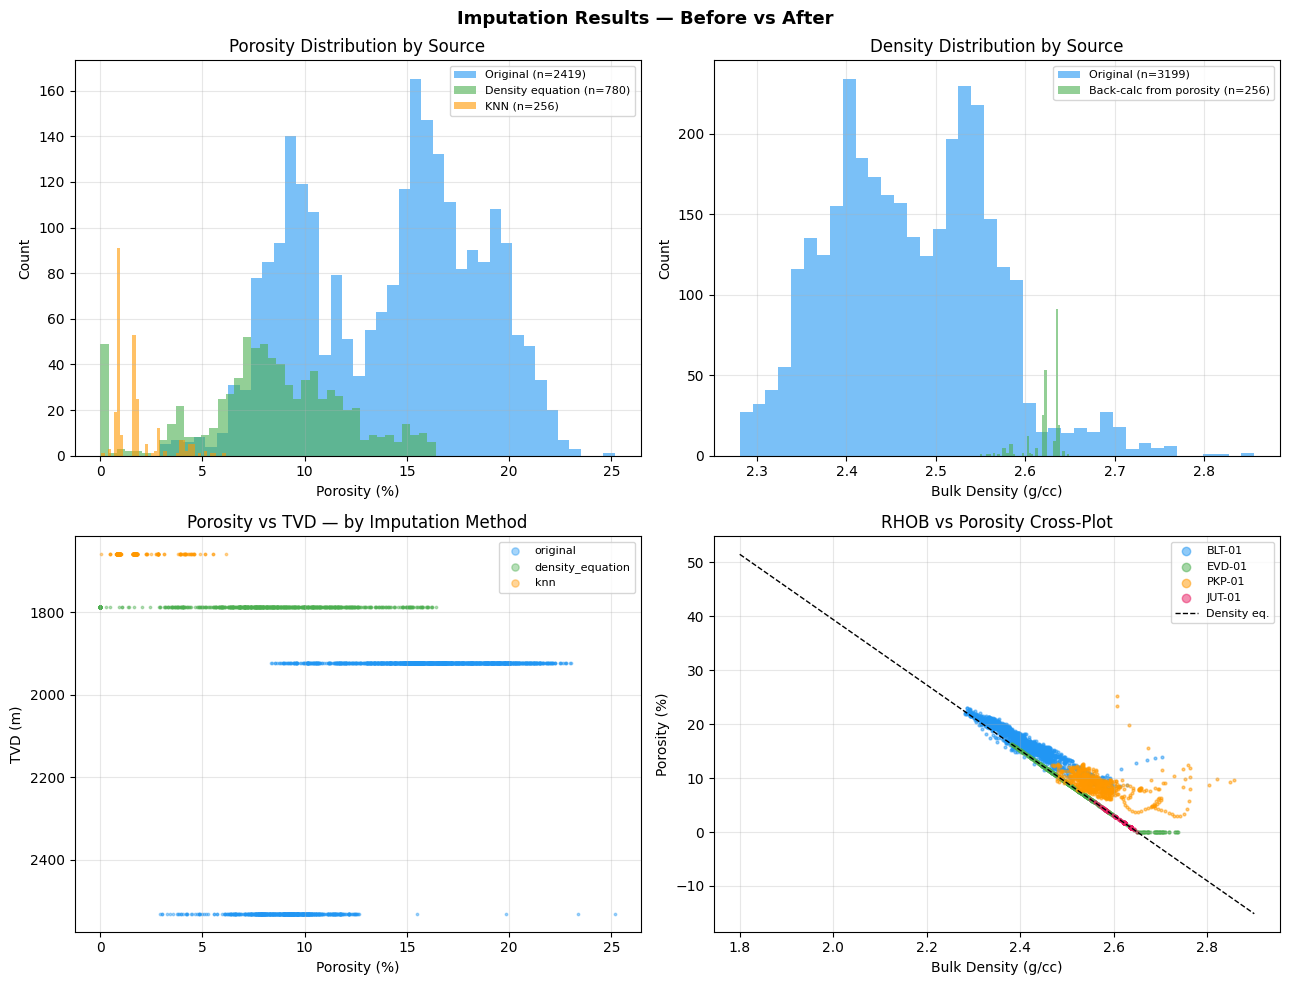

Figure saved.


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Imputation Results — Before vs After', fontsize=13, fontweight='bold')

# ── Top left: Porosity distribution by imputation method ──
ax = axes[0, 0]
for method, color, label in [
    ('original',         '#2196F3', 'Original'),
    ('density_equation', '#4CAF50', 'Density equation'),
    ('knn',              '#FF9800', 'KNN')
]:
    subset = df_clean[df_clean['porosity_imputation_method'] == method][por_col]
    if len(subset) > 0:
        ax.hist(subset, bins=40, alpha=0.6, color=color,
                label=f'{label} (n={len(subset)})')
ax.set_xlabel('Porosity (%)')
ax.set_ylabel('Count')
ax.set_title('Porosity Distribution by Source')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── Top right: Density distribution by imputation method ──
ax = axes[0, 1]
for method, color, label in [
    ('original',                  '#2196F3', 'Original'),
    ('back_calc_from_porosity',   '#4CAF50', 'Back-calc from porosity'),
    ('knn',                       '#FF9800', 'KNN')
]:
    subset = df_clean[df_clean['density_imputation_method'] == method][dens_col]
    if len(subset) > 0:
        ax.hist(subset, bins=40, alpha=0.6, color=color,
                label=f'{label} (n={len(subset)})')
ax.set_xlabel('Bulk Density (g/cc)')
ax.set_ylabel('Count')
ax.set_title('Density Distribution by Source')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# ── Bottom left: Porosity vs depth per well (coloured by imputation method) ──
ax = axes[1, 0]
method_colors = {'original': '#2196F3', 'density_equation': '#4CAF50', 'knn': '#FF9800'}
for method, color in method_colors.items():
    mask = df_clean['porosity_imputation_method'] == method
    ax.scatter(df_clean.loc[mask, por_col],
               df_clean.loc[mask, 'depth_tvd_m'],
               s=3, alpha=0.4, color=color, label=method)
ax.invert_yaxis()
ax.set_xlabel('Porosity (%)')
ax.set_ylabel('TVD (m)')
ax.set_title('Porosity vs TVD — by Imputation Method')
ax.legend(fontsize=8, markerscale=3)
ax.grid(alpha=0.3)

# ── Bottom right: Porosity vs density cross-plot ──
ax = axes[1, 1]
for well in WELLS:
    mask = df_clean['well_id'] == well
    ax.scatter(df_clean.loc[mask, dens_col],
               df_clean.loc[mask, por_col],
               s=4, alpha=0.5, color=COLORS[well], label=well)
# Overlay the density-porosity line
rhob_line = np.linspace(1.8, 2.9, 100)
por_line  = density_porosity(rhob_line) * 100
ax.plot(rhob_line, por_line, 'k--', linewidth=1, label='Density eq.')
ax.set_xlabel('Bulk Density (g/cc)')
ax.set_ylabel('Porosity (%)')
ax.set_title('RHOB vs Porosity Cross-Plot')
ax.legend(fontsize=8, markerscale=3)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, '03_imputation_results.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')

## 10. Final Missing Data Check

In [20]:
print('Missing data summary (AFTER all fixes):')
print(df_clean.isnull().sum())
print()

# Per-well summary
print('Per-well completeness:')
for well in WELLS:
    mask = df_clean['well_id'] == well
    sub  = df_clean[mask]
    print(f'\n  {well} ({mask.sum()} rows):')
    print(f'    depth_tvd_m missing:    {sub["depth_tvd_m"].isnull().sum()}')
    print(f'    porosity_pct missing:   {sub[por_col].isnull().sum()}')
    print(f'    bulk_density missing:   {sub[dens_col].isnull().sum()}')
    print(f'    Porosity range:         {sub[por_col].min():.1f} – {sub[por_col].max():.1f} %')
    print(f'    TVD range:              {sub["depth_tvd_m"].min():.1f} – {sub["depth_tvd_m"].max():.1f} m')

Missing data summary (AFTER all fixes):
well_id                       0
easting                       0
northing                      0
depth_tvd_m                   0
porosity_pct                  0
gamma_ray_api                 0
bulk_density_gcc              0
formation_top_tvd             0
formation_base_tvd            0
formation_thickness_m         0
distance_to_usp_km            0
flag                          0
flag_reason                   0
porosity_imputation_method    0
density_imputation_method     0
dtype: int64

Per-well completeness:

  BLT-01 (1689 rows):
    depth_tvd_m missing:    0
    porosity_pct missing:   0
    bulk_density missing:   0
    Porosity range:         8.4 – 23.0 %
    TVD range:              1924.0 – 1924.0 m

  EVD-01 (780 rows):
    depth_tvd_m missing:    0
    porosity_pct missing:   0
    bulk_density missing:   0
    Porosity range:         0.0 – 16.4 %
    TVD range:              1788.0 – 1788.0 m

  PKP-01 (730 rows):
    depth_tvd_m missin

## 11. Save Cleaned Dataset

In [21]:
output_path = os.path.join(PROC_DIR, 'target_lithologies_clean.csv')
df_clean.to_csv(output_path, index=False)
print(f'Cleaned dataset saved to: {output_path}')
print(f'Shape: {df_clean.shape}')
print(f'Columns: {df_clean.columns.tolist()}')

Cleaned dataset saved to: ../outputs/processed_data/target_lithologies_clean.csv
Shape: (3455, 15)
Columns: ['well_id', 'easting', 'northing', 'depth_tvd_m', 'porosity_pct', 'gamma_ray_api', 'bulk_density_gcc', 'formation_top_tvd', 'formation_base_tvd', 'formation_thickness_m', 'distance_to_usp_km', 'flag', 'flag_reason', 'porosity_imputation_method', 'density_imputation_method']


## 12. Notebook Summary

In [22]:
print('Figures generated:')
figs = [f for f in os.listdir(FIGURES_DIR) if f.startswith('03_')]
for f in sorted(figs):
    print(f'  {f}')

print()
print('Fixes applied:')
print('  1. JUT-01 measured depths converted from feet to metres (x 0.3048)')
print('  2. depth_tvd_m computed for all wells via directional survey interpolation')
print('  3. porosity_pct imputed using density-porosity equation (where RHOB available)')
print('  4. porosity_pct remaining gaps filled via KNN (GR + TVD as predictors)')
print('  5. bulk_density_gcc back-calculated from porosity where possible, then KNN')
print('  6. All values clamped to physical bounds')
print()
print('Output: outputs/processed_data/target_lithologies_clean.csv')
print()
print('Next: Notebook 04 — Reservoir Characterization')

Figures generated:
  03_imputation_results.png
  03_porosity_validation.png
  03_tvd_conversion_check.png

Fixes applied:
  1. JUT-01 measured depths converted from feet to metres (x 0.3048)
  2. depth_tvd_m computed for all wells via directional survey interpolation
  3. porosity_pct imputed using density-porosity equation (where RHOB available)
  4. porosity_pct remaining gaps filled via KNN (GR + TVD as predictors)
  5. bulk_density_gcc back-calculated from porosity where possible, then KNN
  6. All values clamped to physical bounds

Output: outputs/processed_data/target_lithologies_clean.csv

Next: Notebook 04 — Reservoir Characterization
